# 1. Импорт библиотек и функций

## 1.1. Библиотеки

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader
from torch import nn, optim

from dataset import StockDataset
from model import StockLSTMRegressor
from train import train, calculate_metrics

import warnings
warnings.filterwarnings('ignore')

## 1.2. Функции

In [2]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    df = df.sort_values('begin').reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

In [15]:
def visualize_predictions_comparison(results_df, title="Сравнение реальных и предсказанных изменений"):
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    results_df = results_df.sort_values('begin')
    
    plt.figure(figsize=(16, 8))
    
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=2, color='#2E8B57', label='Реальное изменение', marker='o', markersize=3, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=2, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=3, alpha=0.8)
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Изменение цены (%)', fontsize=12)
    plt.xlabel('Дата', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca()
    
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 2. Загрузка данных

## 2.1. Список тикеров

In [4]:
tickers = [
    'SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN'
]

## 2.2. Чтение

In [5]:
data_SBER = pd.read_csv("../../data/stock_features_data/stocks_features_SBER.csv")
data_TCSG = pd.read_csv("../../data/stock_features_data/stocks_features_TCSG.csv")
data_GAZP = pd.read_csv("../../data/stock_features_data/stocks_features_GAZP.csv")
data_LKOH = pd.read_csv("../../data/stock_features_data/stocks_features_LKOH.csv")
data_ROSN = pd.read_csv("../../data/stock_features_data/stocks_features_ROSN.csv")

In [6]:
data_SBER.drop('target_class', axis=1, inplace=True)
data_TCSG.drop('target_class', axis=1, inplace=True)
data_GAZP.drop('target_class', axis=1, inplace=True)
data_LKOH.drop('target_class', axis=1, inplace=True)
data_ROSN.drop('target_class', axis=1, inplace=True)

## 2.3. Разделение на train/test

In [7]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=data_SBER, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=data_TCSG, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=data_GAZP, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=data_LKOH, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=data_ROSN, 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84


# 3. Обучение LSTM

## 3.1. Сбер

### 3.1.1. Параметры

In [170]:
SEQUENCE_LENGTH = 9
BATCH_SIZE = 8
HIDDEN_SIZE = 8
NUM_LAYERS = 1
DROPOUT = 0.7
NUM_EPOCHS = 10
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.01

### 3.1.2. Датасеты

In [171]:
train_dataset = StockDataset(X_train_SBER, y_train_SBER, sequence_length=SEQUENCE_LENGTH)
test_dataset = StockDataset(X_test_SBER, y_test_SBER, sequence_length=SEQUENCE_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Создано 3334 последовательностей длины 9
Количество признаков: 84
Создано 828 последовательностей длины 9
Количество признаков: 84


### 3.1.3. Модель

In [172]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [173]:
model = StockLSTMRegressor(
    input_size=train_dataset.num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

Всего параметров: 3,017


### 3.1.4. Обучение

In [174]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

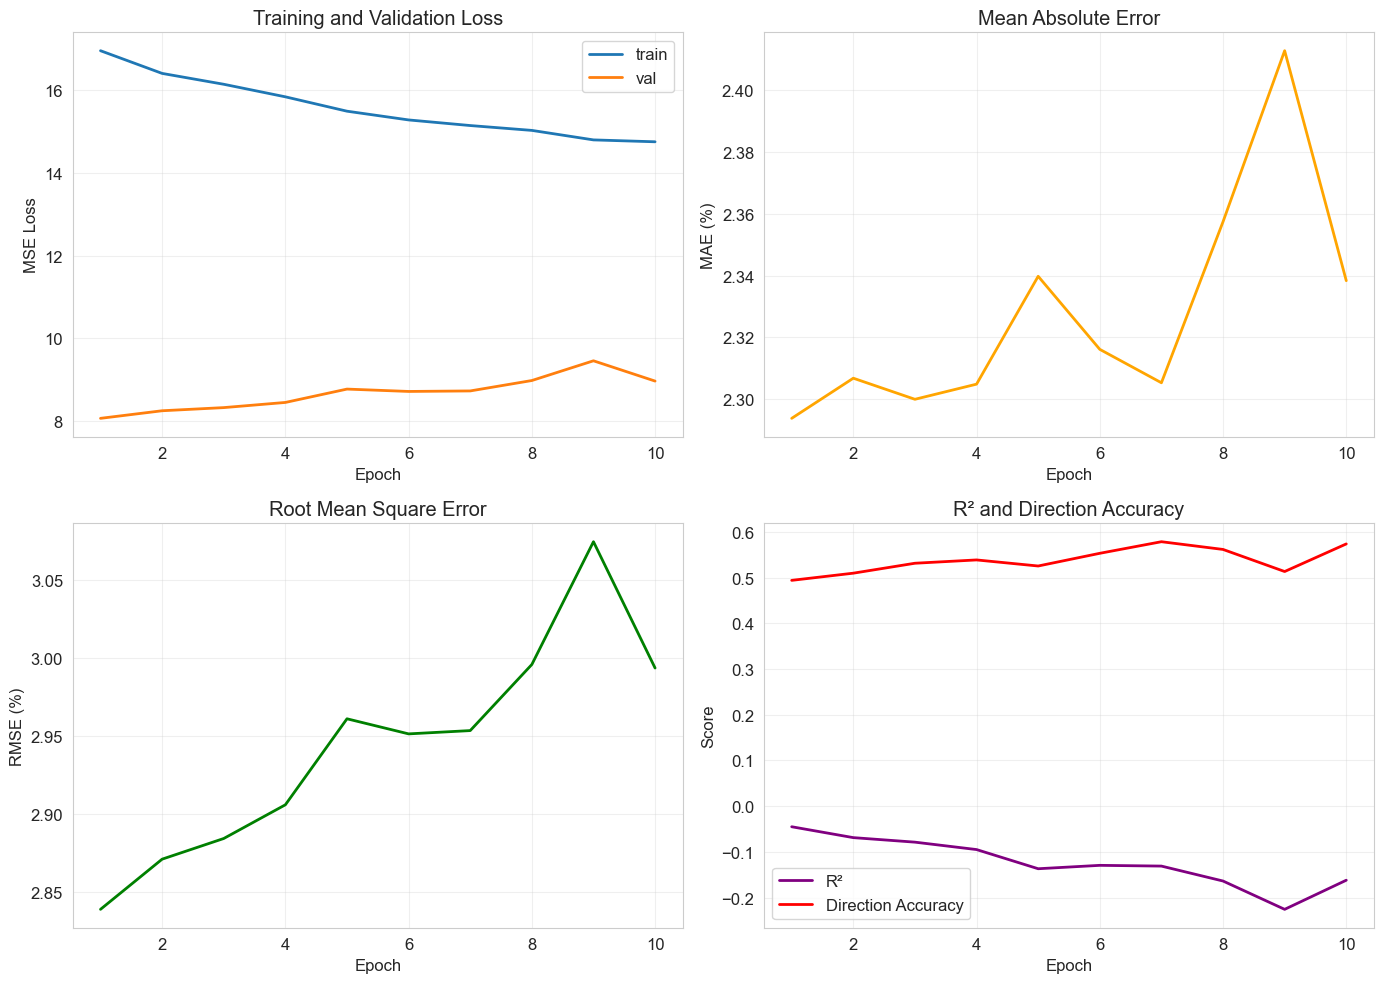


Epoch 10/10:
  Train Loss: 14.752986
  Val Loss:   8.959620
  MAE:  2.3383%
  RMSE: 2.9933%
  R²:   -0.1621
  Dir Acc: 0.5737


In [175]:
train_losses, val_losses, val_metrics = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS
)

### 3.1.5. Визуализация и сохранение

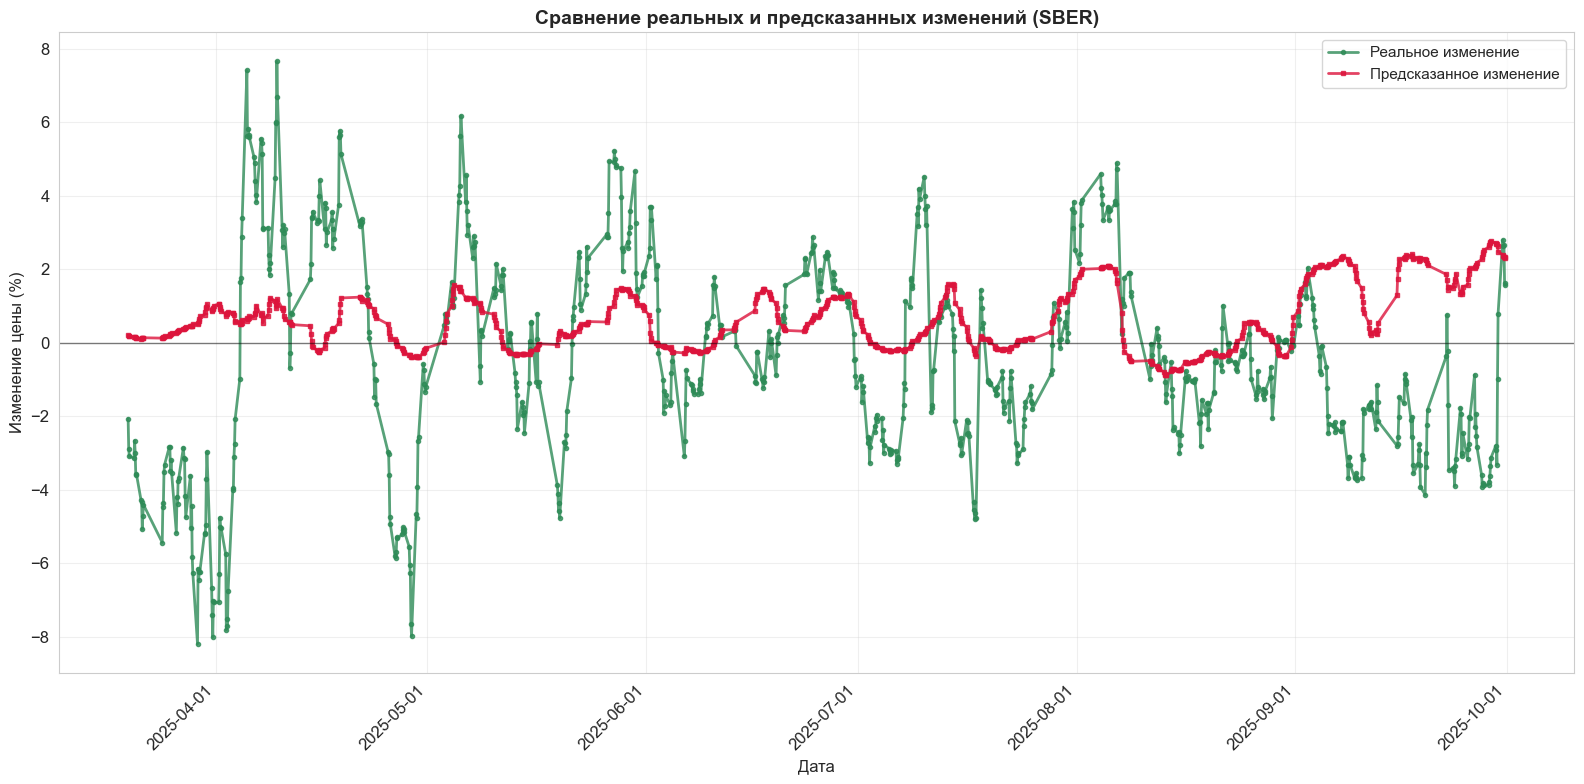

In [176]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for features, targets, lengths in test_loader:
        features = features.to(device)
        predictions = model(features, lengths.to(device))
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

final_metrics = calculate_metrics(np.array(all_targets), np.array(all_predictions))

results_df = pd.DataFrame({
    'begin': data_SBER.iloc[-len(all_predictions):]['begin'].values,
    'target_price_change': all_targets,
    'predict': all_predictions
})

visualize_predictions_comparison(
    results_df, 
    title="Сравнение реальных и предсказанных изменений (SBER)"
)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': train_dataset.num_features,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_names': train_dataset.feature_names,
    'X_mean': train_dataset.X_mean,
    'X_std': train_dataset.X_std,
    'metrics': final_metrics
}

torch.save(checkpoint, 'lstm_stock_regressor_SBER.pt')

## 3.2. Тинькофф

### 3.2.1. Параметры

In [23]:
SEQUENCE_LENGTH = 9
BATCH_SIZE = 8
HIDDEN_SIZE = 24
NUM_LAYERS = 1
DROPOUT = 0.5
NUM_EPOCHS = 7
LEARNING_RATE = 0.000486524646123166
WEIGHT_DECAY = 0.020866570318598624

### 3.2.2. Датасеты

In [24]:
train_dataset = StockDataset(X_train_TCSG, y_train_TCSG, sequence_length=SEQUENCE_LENGTH)
test_dataset = StockDataset(X_test_TCSG, y_test_TCSG, sequence_length=SEQUENCE_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Создано 2274 последовательностей длины 9
Количество признаков: 84
Создано 563 последовательностей длины 9
Количество признаков: 84


### 3.2.3. Модель

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [54]:
model = StockLSTMRegressor(
    input_size=train_dataset.num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

Всего параметров: 10,585


### 3.2.4. Обучение

In [55]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

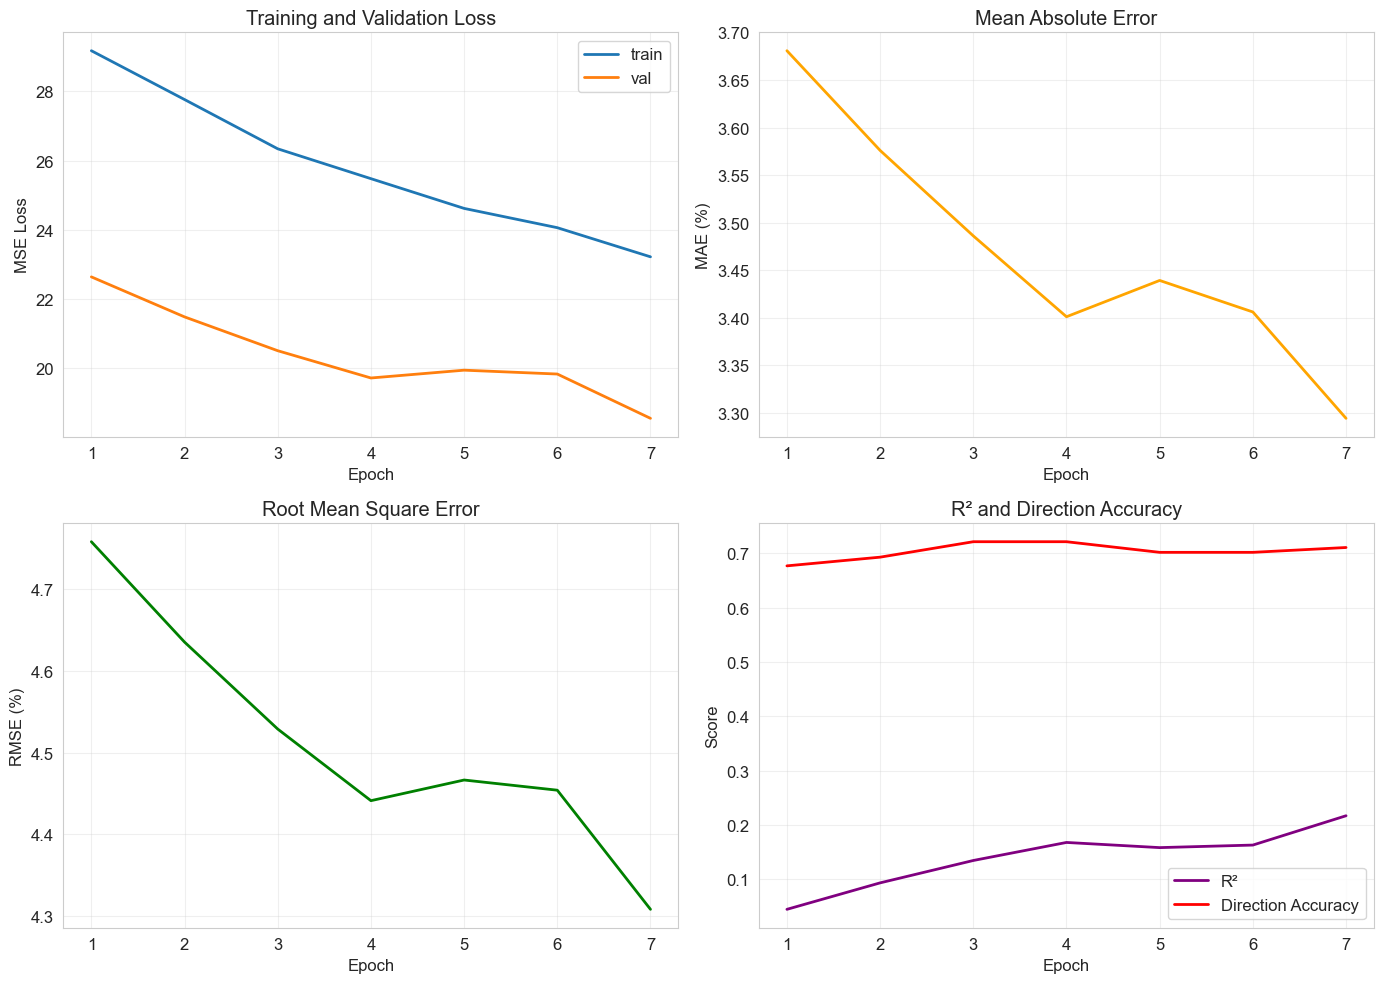


Epoch 7/7:
  Train Loss: 23.221340
  Val Loss:   18.561561
  MAE:  3.2943%
  RMSE: 4.3083%
  R²:   0.2171
  Dir Acc: 0.7105


In [56]:
train_losses, val_losses, val_metrics = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS
)

### 3.2.5. Визуализация и сохранение

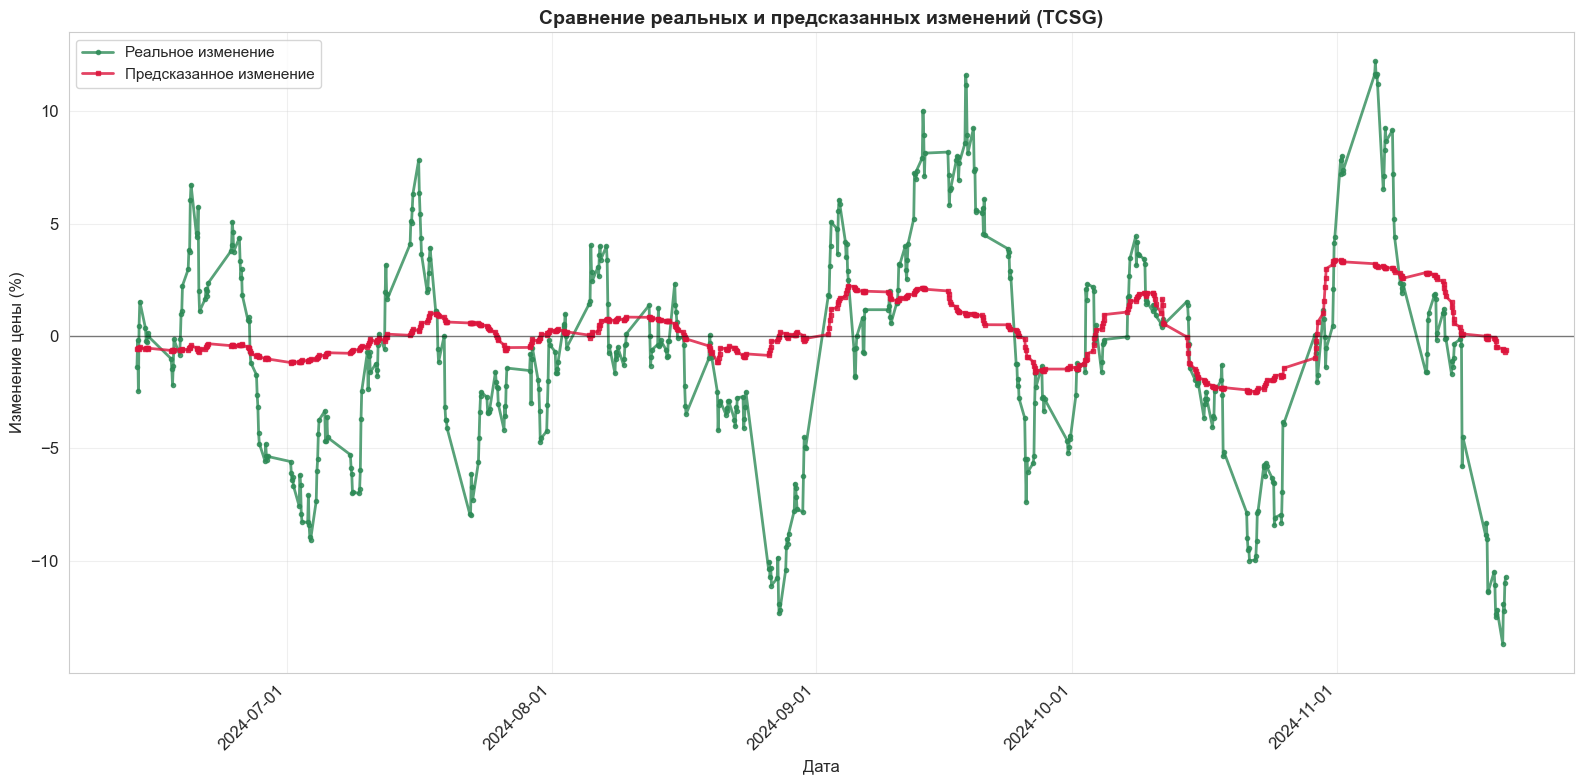

In [57]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for features, targets, lengths in test_loader:
        features = features.to(device)
        predictions = model(features, lengths.to(device))
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

final_metrics = calculate_metrics(np.array(all_targets), np.array(all_predictions))

results_df = pd.DataFrame({
    'begin': data_TCSG.iloc[-len(all_predictions):]['begin'].values,
    'target_price_change': all_targets,
    'predict': all_predictions
})

visualize_predictions_comparison(
    results_df, 
    title="Сравнение реальных и предсказанных изменений (TCSG)"
)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': train_dataset.num_features,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_names': train_dataset.feature_names,
    'X_mean': train_dataset.X_mean,
    'X_std': train_dataset.X_std,
    'metrics': final_metrics
}

torch.save(checkpoint, 'lstm_stock_regressor_TCSG.pt')

## 3.3. Газпром

### 3.3.1. Параметры

In [58]:
SEQUENCE_LENGTH = 3
BATCH_SIZE = 8
HIDDEN_SIZE = 28
NUM_LAYERS = 1
DROPOUT = 0.3
NUM_EPOCHS = 10
LEARNING_RATE = 0.0008975417015618482
WEIGHT_DECAY = 0.01351704376108571

### 3.3.2. Датасеты

In [59]:
train_dataset = StockDataset(X_train_GAZP, y_train_GAZP, sequence_length=SEQUENCE_LENGTH)
test_dataset = StockDataset(X_test_GAZP, y_test_GAZP, sequence_length=SEQUENCE_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Создано 3340 последовательностей длины 3
Количество признаков: 84
Создано 834 последовательностей длины 3
Количество признаков: 84


### 3.3.3. Модель

In [60]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [61]:
model = StockLSTMRegressor(
    input_size=train_dataset.num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

Всего параметров: 12,797


### 3.3.4. Обучение

In [62]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

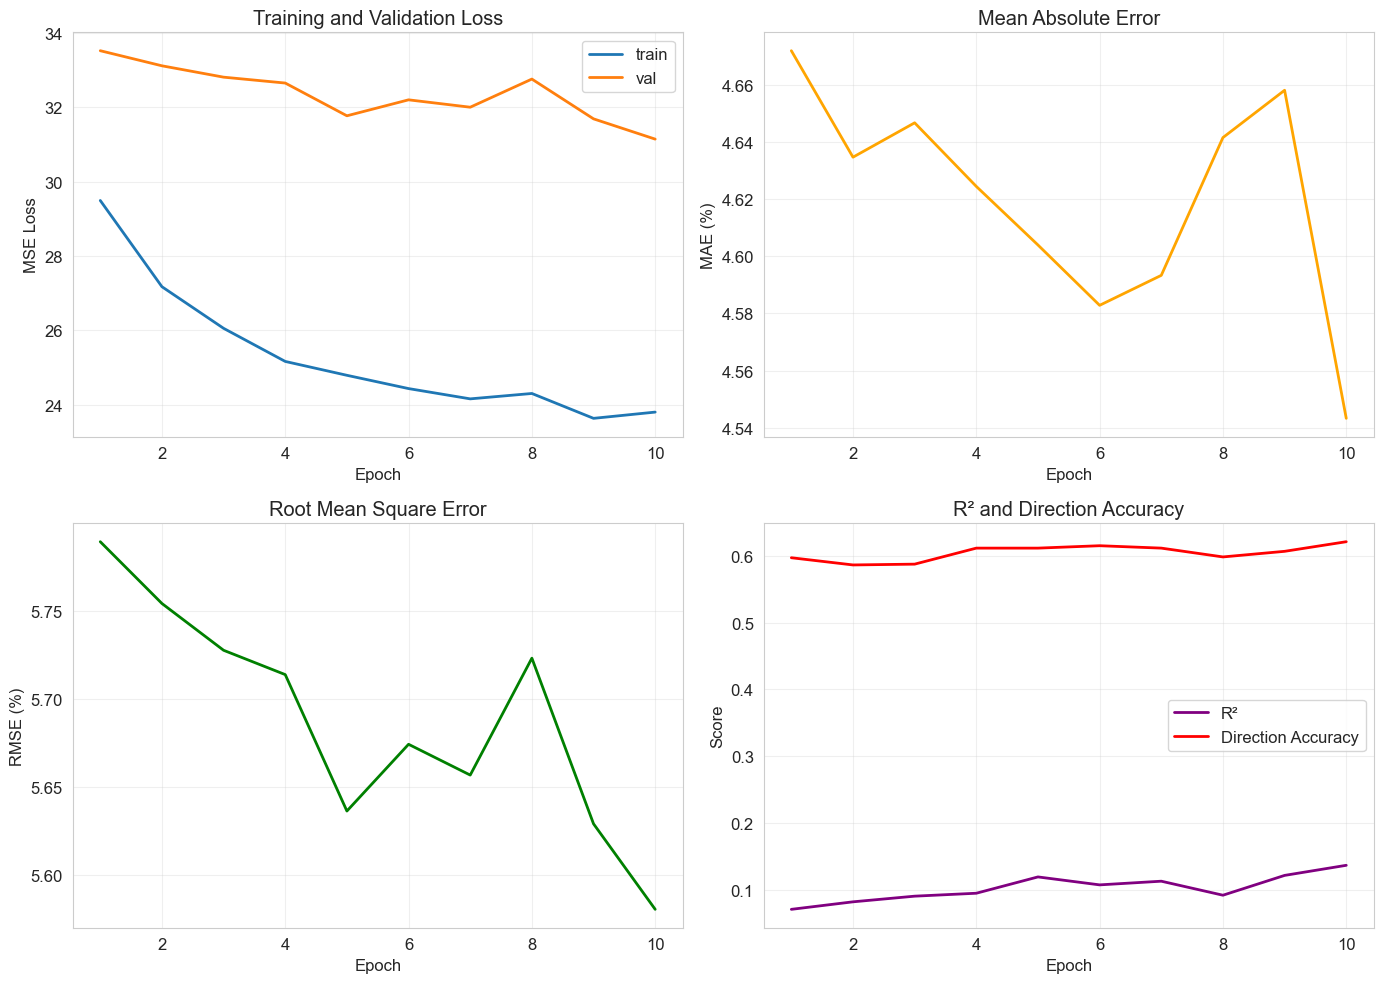


Epoch 10/10:
  Train Loss: 23.798137
  Val Loss:   31.140108
  MAE:  4.5434%
  RMSE: 5.5803%
  R²:   0.1367
  Dir Acc: 0.6211


In [63]:
train_losses, val_losses, val_metrics = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS
)

### 3.3.5. Визуализация и сохранение

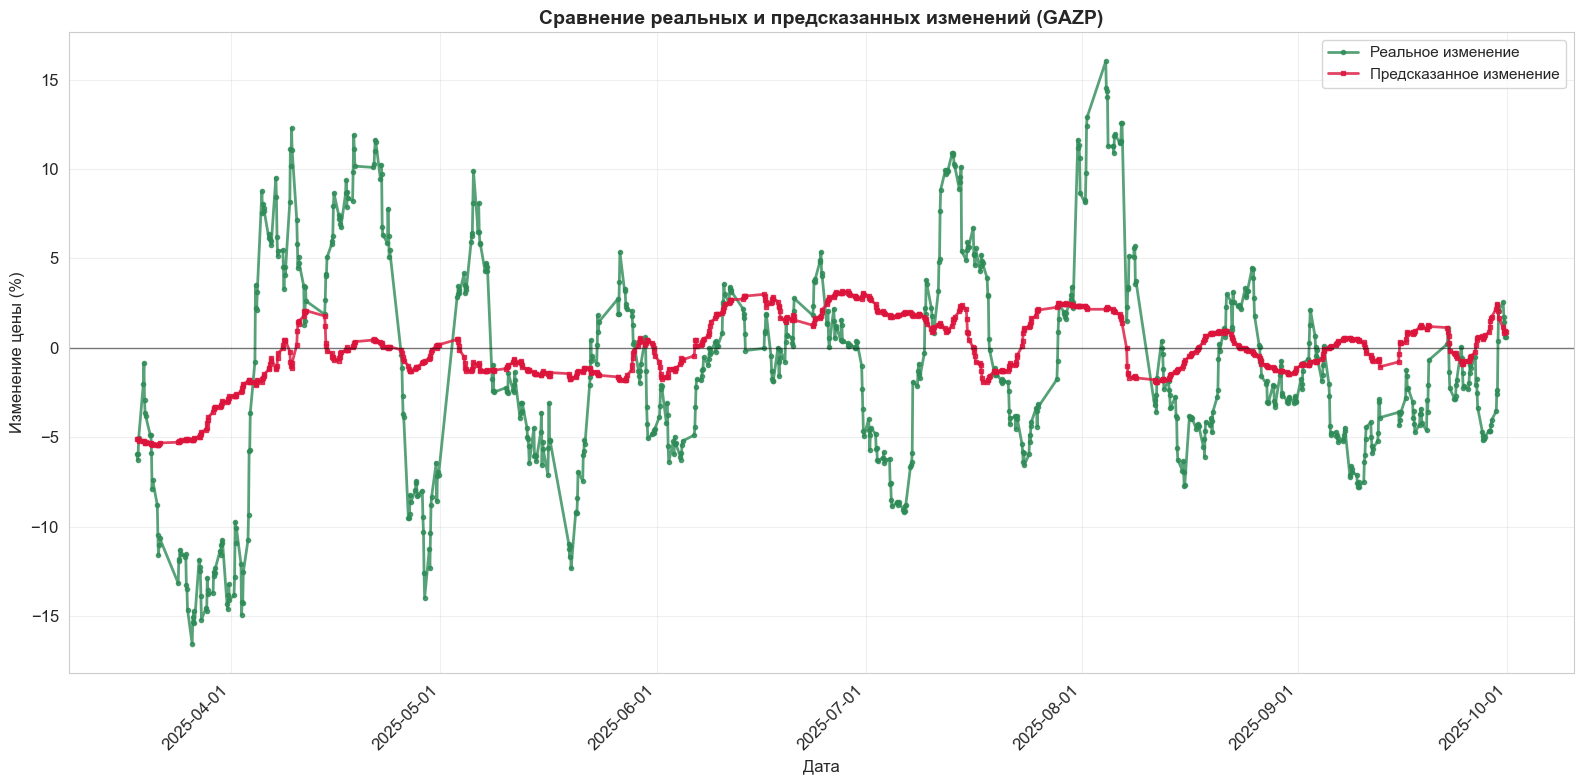

In [64]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for features, targets, lengths in test_loader:
        features = features.to(device)
        predictions = model(features, lengths.to(device))
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

final_metrics = calculate_metrics(np.array(all_targets), np.array(all_predictions))

results_df = pd.DataFrame({
    'begin': data_GAZP.iloc[-len(all_predictions):]['begin'].values,
    'target_price_change': all_targets,
    'predict': all_predictions
})

visualize_predictions_comparison(
    results_df, 
    title="Сравнение реальных и предсказанных изменений (GAZP)"
)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': train_dataset.num_features,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_names': train_dataset.feature_names,
    'X_mean': train_dataset.X_mean,
    'X_std': train_dataset.X_std,
    'metrics': final_metrics
}

torch.save(checkpoint, 'lstm_stock_regressor_GAZP.pt')

## 3.4. Лукойл

### 3.4.1. Параметры

In [197]:
SEQUENCE_LENGTH = 5
BATCH_SIZE = 8
HIDDEN_SIZE = 8
NUM_LAYERS = 1
DROPOUT = 0.7
NUM_EPOCHS = 10
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.01

### 3.4.2. Датасеты

In [198]:
train_dataset = StockDataset(X_train_LKOH, y_train_LKOH, sequence_length=SEQUENCE_LENGTH)
test_dataset = StockDataset(X_test_LKOH, y_test_LKOH, sequence_length=SEQUENCE_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Создано 3338 последовательностей длины 5
Количество признаков: 84
Создано 832 последовательностей длины 5
Количество признаков: 84


### 3.4.3. Модель

In [199]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [200]:
model = StockLSTMRegressor(
    input_size=train_dataset.num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

Всего параметров: 3,017


### 3.4.4. Обучение

In [201]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

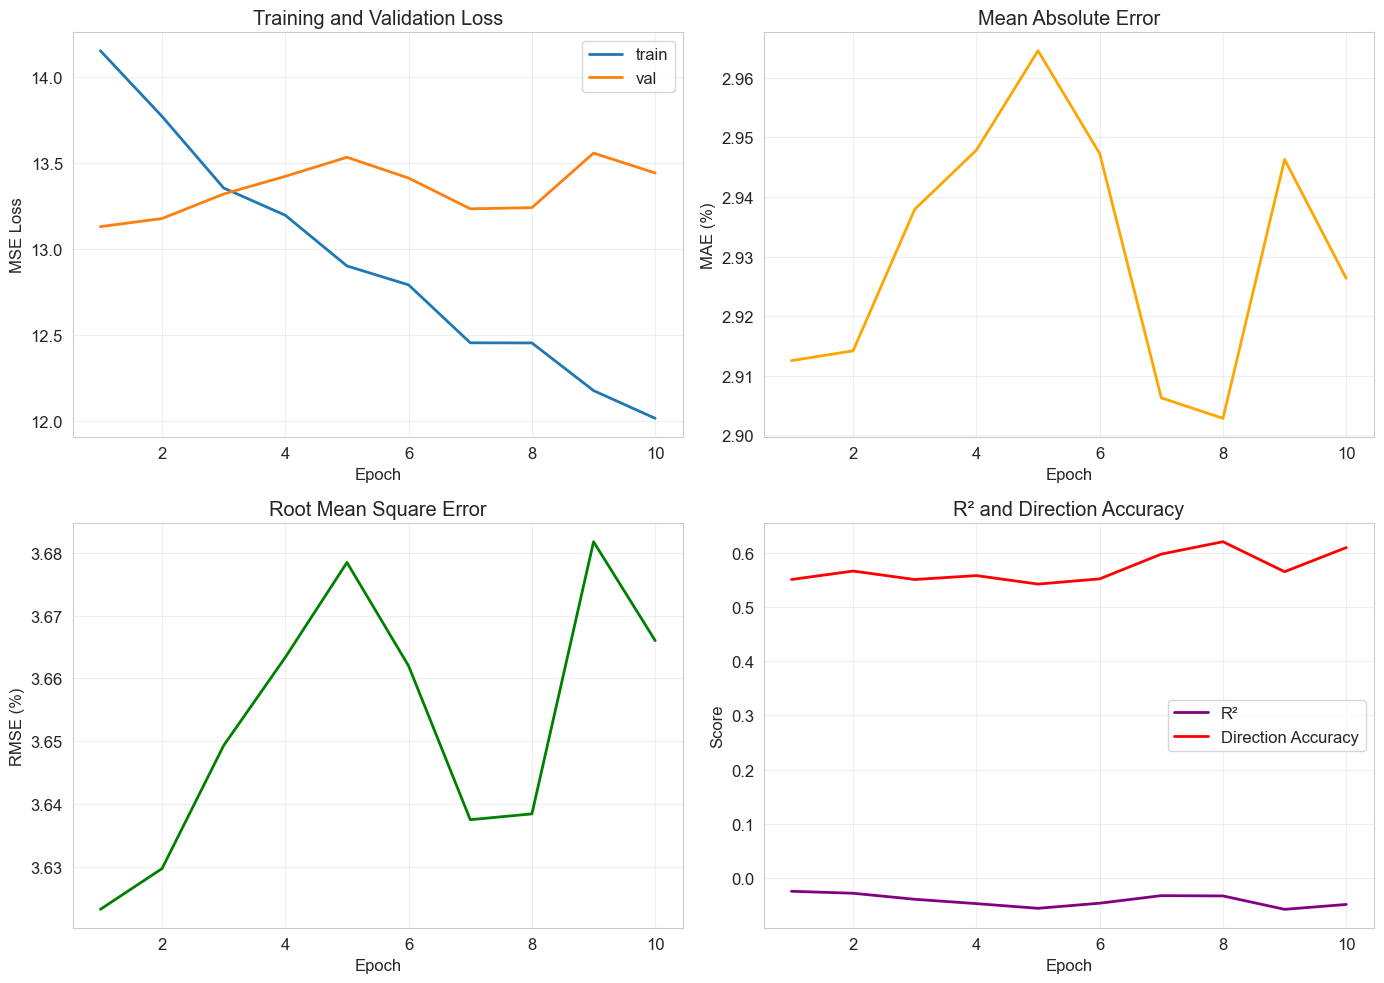


Epoch 10/10:
  Train Loss: 12.014864
  Val Loss:   13.439698
  MAE:  2.9263%
  RMSE: 3.6660%
  R²:   -0.0487
  Dir Acc: 0.6094


In [202]:
train_losses, val_losses, val_metrics = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS
)

### 3.4.5. Визуализация и сохранение

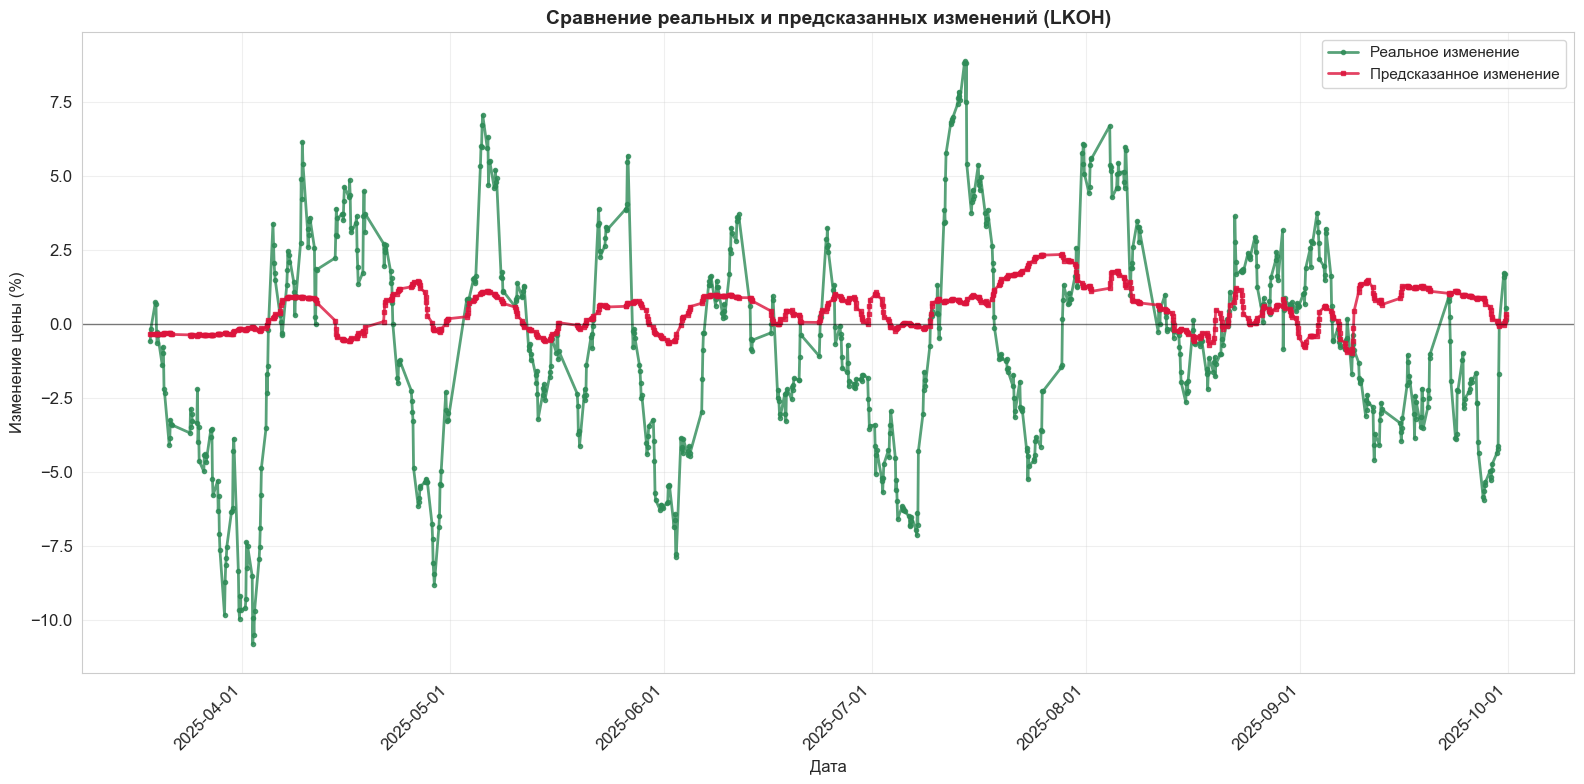

In [203]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for features, targets, lengths in test_loader:
        features = features.to(device)
        predictions = model(features, lengths.to(device))
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

final_metrics = calculate_metrics(np.array(all_targets), np.array(all_predictions))

results_df = pd.DataFrame({
    'begin': data_LKOH.iloc[-len(all_predictions):]['begin'].values,
    'target_price_change': all_targets,
    'predict': all_predictions
})

visualize_predictions_comparison(
    results_df, 
    title="Сравнение реальных и предсказанных изменений (LKOH)"
)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': train_dataset.num_features,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_names': train_dataset.feature_names,
    'X_mean': train_dataset.X_mean,
    'X_std': train_dataset.X_std,
    'metrics': final_metrics
}

torch.save(checkpoint, 'lstm_stock_regressor_LKOH.pt')

## 3.5. Роснефть

### 3.5.1. Параметры

In [120]:
SEQUENCE_LENGTH = 5
BATCH_SIZE = 8
HIDDEN_SIZE = 12
NUM_LAYERS = 1
DROPOUT = 0.4
NUM_EPOCHS = 7
LEARNING_RATE = 0.00017452875019561466
WEIGHT_DECAY = 0.007793958814250874

### 3.5.2. Датасеты

In [121]:
train_dataset = StockDataset(X_train_ROSN, y_train_ROSN, sequence_length=SEQUENCE_LENGTH)
test_dataset = StockDataset(X_test_ROSN, y_test_ROSN, sequence_length=SEQUENCE_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Создано 3338 последовательностей длины 5
Количество признаков: 84
Создано 832 последовательностей длины 5
Количество признаков: 84


### 3.5.3. Модель

In [122]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [127]:
model = StockLSTMRegressor(
    input_size=train_dataset.num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

Всего параметров: 4,717


### 3.5.4. Обучение

In [128]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

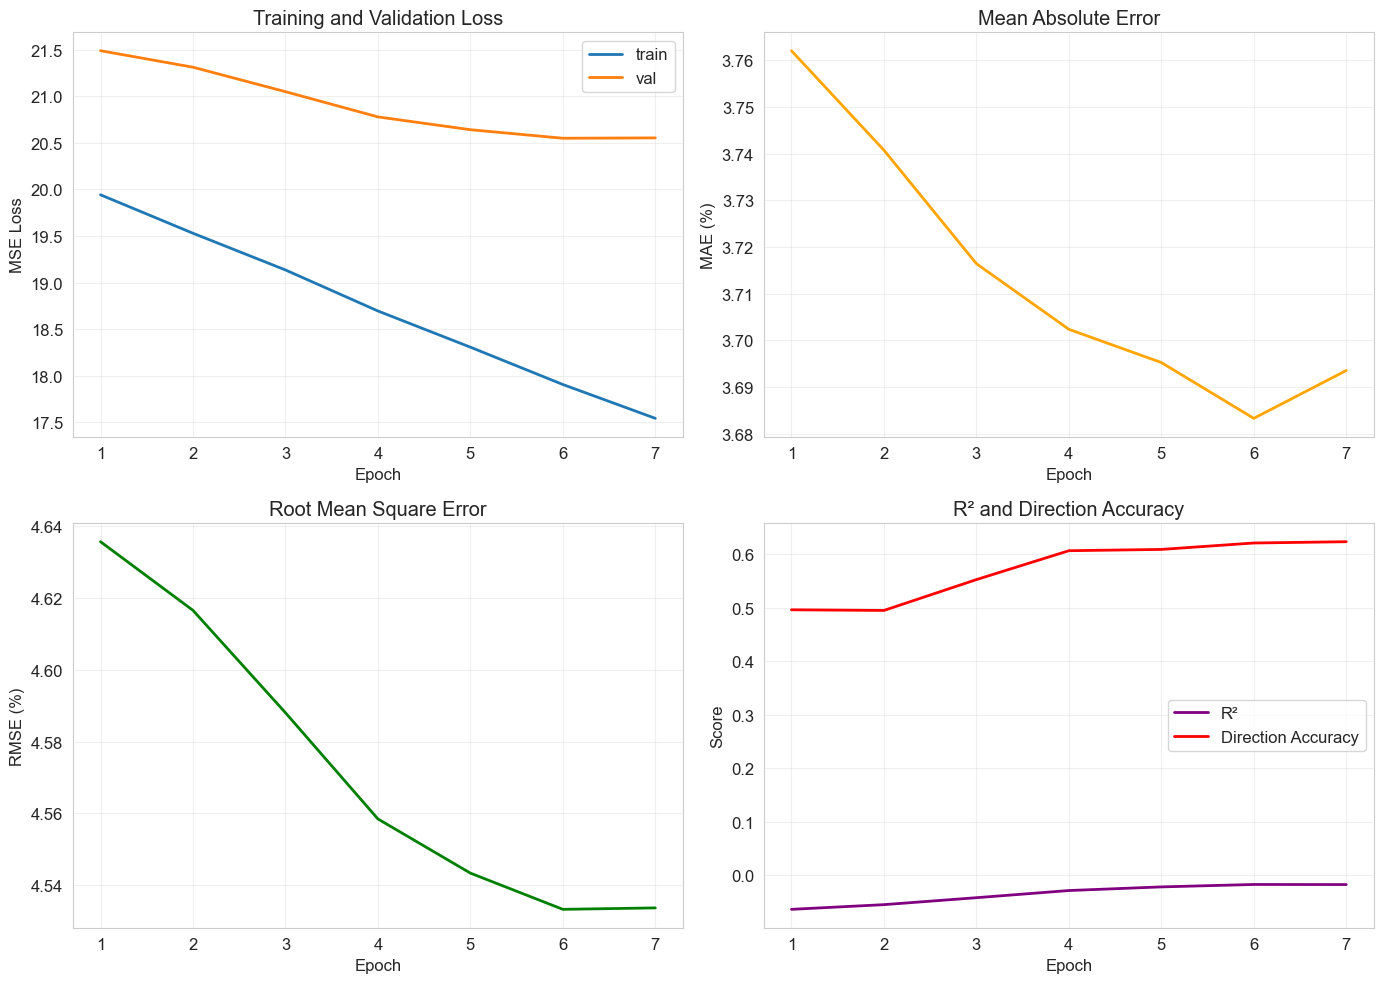


Epoch 7/7:
  Train Loss: 17.542300
  Val Loss:   20.553573
  MAE:  3.6936%
  RMSE: 4.5336%
  R²:   -0.0178
  Dir Acc: 0.6238


In [129]:
train_losses, val_losses, val_metrics = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS,
)

### 3.5.5. Визуализация и сохранение

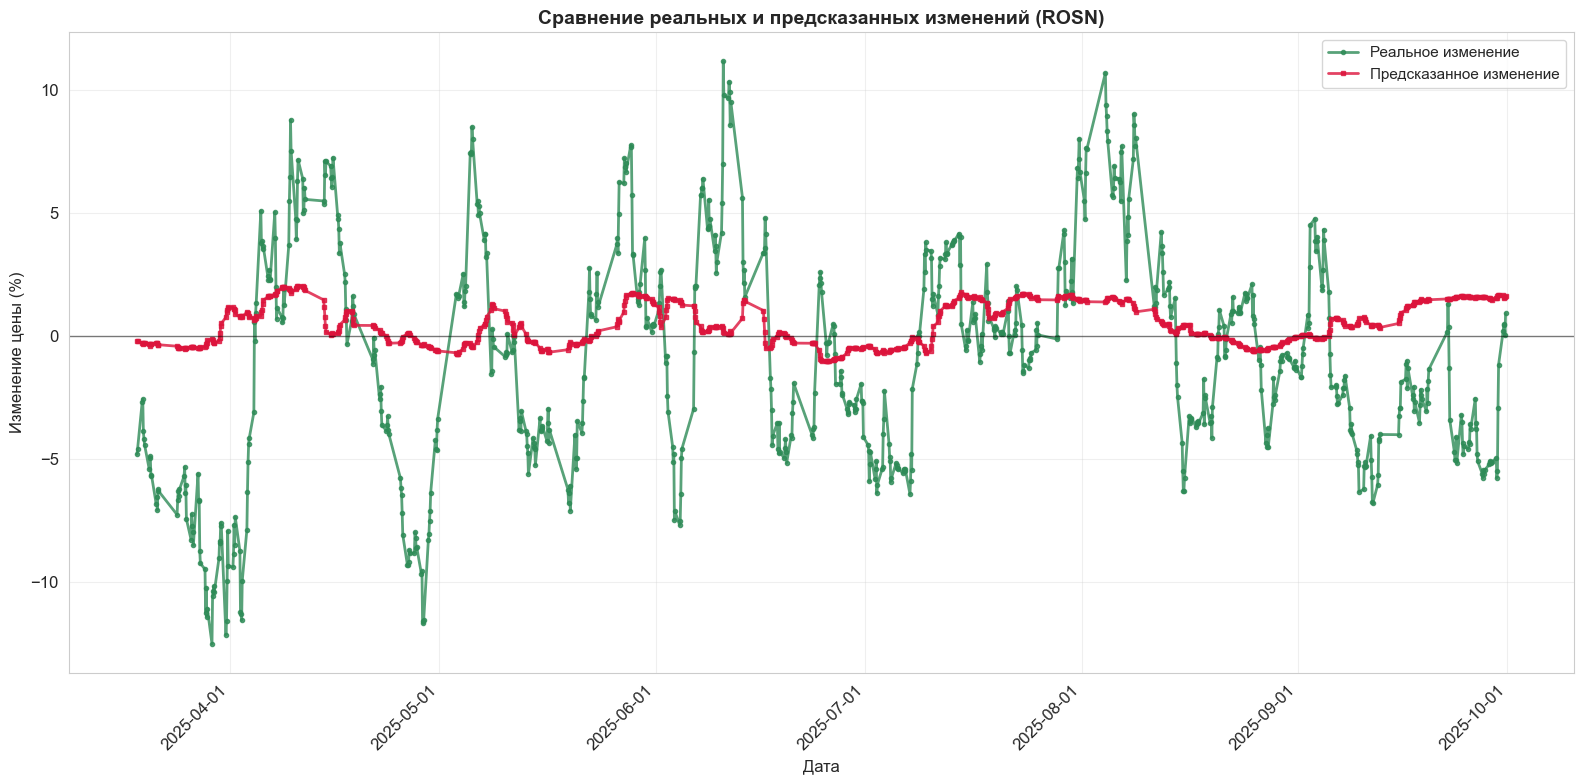

In [130]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for features, targets, lengths in test_loader:
        features = features.to(device)
        predictions = model(features, lengths.to(device))
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

final_metrics = calculate_metrics(np.array(all_targets), np.array(all_predictions))

results_df = pd.DataFrame({
    'begin': data_ROSN.iloc[-len(all_predictions):]['begin'].values,
    'target_price_change': all_targets,
    'predict': all_predictions
})

visualize_predictions_comparison(
    results_df, 
    title="Сравнение реальных и предсказанных изменений (ROSN)"
)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': train_dataset.num_features,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_names': train_dataset.feature_names,
    'X_mean': train_dataset.X_mean,
    'X_std': train_dataset.X_std,
    'metrics': final_metrics
}

torch.save(checkpoint, 'lstm_stock_regressor_ROSN.pt')

# Вывод

Параметры подбирались вручную и отдельно с помощью оптуны . Так как данных для обучения LSTM не так много, то модельки делались максимально простыми. В целом, по каждой акции есть прирост качества, но в некоторых случаях, таких как Сбер и Лукойл, где нет падения лоса в принципе даже с подбором параметров, существует некий трейд-офф между accuracy-направления и остальными метриками (С подбором параметров визуализация выглядит почти как прямая линия, что говорит о том, что модели легче предсказывать среднее, поэтому в данных акциях больше упор был сделан на accuracy-направления). В большинстве случаев визуализации не отображают качество модели и реальная смелось в прогнозах появляется с некоторым переобучением, что ведет за собой потери в метриках.